In [1]:
from astropy.table import Table 
import numpy as np

# load data onto an astropy table
jades_path = '/home/caltech-msanche3/data/JADES_north_fits_data.fits'
jades_data = Table.read(jades_path, hdu='CIRC_BSUB',format='fits')
# change units of flux from nJy to microJy so eazy fits correctly
print(jades_data.colnames)
for col in jades_data.colnames:
    if '_CIRC1' in col or '_ei' in col:
        jades_data[col] = jades_data[col] * 0.001
redshift = Table.read(jades_path, hdu='PHOTOZ_KRON',format='fits')


['ID', 'RA', 'DEC', 'F070W_CIRC0', 'F070W_CIRC0_bkg', 'F070W_CIRC0_e', 'F070W_CIRC0_ei', 'F070W_CIRC1', 'F070W_CIRC1_bkg', 'F070W_CIRC1_e', 'F070W_CIRC1_ei', 'F070W_CIRC2', 'F070W_CIRC2_bkg', 'F070W_CIRC2_e', 'F070W_CIRC2_ei', 'F070W_CIRC3', 'F070W_CIRC3_bkg', 'F070W_CIRC3_e', 'F070W_CIRC3_ei', 'F070W_CIRC4', 'F070W_CIRC4_bkg', 'F070W_CIRC4_e', 'F070W_CIRC4_ei', 'F070W_CIRC5', 'F070W_CIRC5_bkg', 'F070W_CIRC5_e', 'F070W_CIRC5_ei', 'F070W_CIRC6', 'F070W_CIRC6_bkg', 'F070W_CIRC6_e', 'F070W_CIRC6_ei', 'F090W_CIRC0', 'F090W_CIRC0_bkg', 'F090W_CIRC0_e', 'F090W_CIRC0_ei', 'F090W_CIRC1', 'F090W_CIRC1_bkg', 'F090W_CIRC1_e', 'F090W_CIRC1_ei', 'F090W_CIRC2', 'F090W_CIRC2_bkg', 'F090W_CIRC2_e', 'F090W_CIRC2_ei', 'F090W_CIRC3', 'F090W_CIRC3_bkg', 'F090W_CIRC3_e', 'F090W_CIRC3_ei', 'F090W_CIRC4', 'F090W_CIRC4_bkg', 'F090W_CIRC4_e', 'F090W_CIRC4_ei', 'F090W_CIRC5', 'F090W_CIRC5_bkg', 'F090W_CIRC5_e', 'F090W_CIRC5_ei', 'F090W_CIRC6', 'F090W_CIRC6_bkg', 'F090W_CIRC6_e', 'F090W_CIRC6_ei', 'F105W_CIRC0',

In [2]:
# ID 12326 is likely not correct and I will be ommiting it for the time being
# there are outliers on this list
# total objs: 7
ids = [1004685,1005591,1026356,1032419,1066336,1089452]
zspec = [7.41,10.60,7.12,6.73,7.13,6.71]
jades_zphot = [9.95,11.09,7.41,6.32,7.13,7.16]
mask = []
for i in range(len(jades_data)):
    if jades_data[i]['ID'] in ids:
        mask.append(True)
    else:
        mask.append(False)

new_jades_data = jades_data[mask]
#new_jades_data.add_column(zspec,name='ZSPEC',index=2)
print(new_jades_data)


   ID       RA       DEC    ... F850LP_CIRC6_e   F850LP_CIRC6_ei   
           deg       deg    ...      nJy               nJy         
------- --------- --------- ... -------------- --------------------
1004685  189.0963  62.23915 ...      16.379108 0.016373903274536132
1005591 189.10603 62.242046 ...      17.657576  0.01764717674255371
1026356 189.10942   62.2388 ...       18.29349  0.01828716278076172
1032419 189.17513  62.28226 ...       16.28495 0.016250062942504882
1066336  189.2593  62.23547 ...      14.322196 0.014320314407348633
1089452 189.18616 62.270878 ...      18.656528 0.018634769439697267


1026356


/tmp/ipykernel_499825/1394976782.py:37: UserWarning: Warning: converting a masked element to nan.
  flux_ujy = np.asarray(flux_ujy, dtype=float)


Text(0.5, 1.0, 'ID: 1026356')

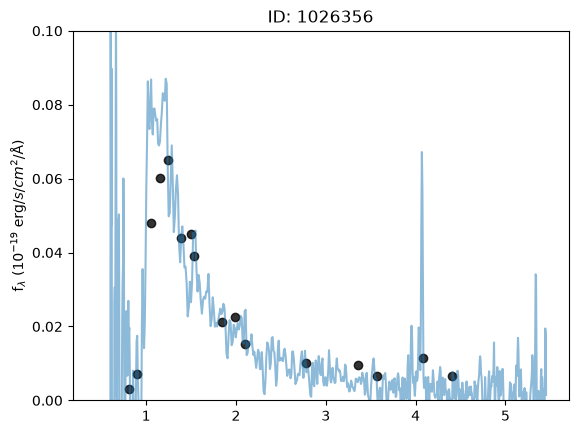

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
filters = Table.read(jades_path, hdu='FILTERS',format='fits')
flux = []
wave = []
bands = [
    'F070W_KRON','F090W_KRON','F105W_KRON','F115W_KRON','F125W_KRON','F140W_KRON','F150W_KRON','F160W_KRON','F162M_KRON',
    'F182M_KRON' ,'F200W_KRON' ,'F210M_KRON' ,'F250M_KRON' ,'F277W_KRON' ,'F300M_KRON' ,'F335M_KRON' ,'F356W_KRON',
    'F410M_KRON' ,'F430M_KRON' ,'F435W_KRON' ,'F444W_KRON' ,'F460M_KRON' ,'F480M_KRON','F606W_KRON' ,'F775W_KRON' ,
    'F814W_KRON' ,'F850LP_KRON' 
]
fil = [
    'F070W','F090W','F105W','F115W','F125W','F140W','F150W','F160W','F162M',
    'F182M' ,'F200W' ,'F210M' ,'F250M' ,'F277W' ,'F300M' ,'F335M' ,'F356W',
    'F410M' ,'F430M' ,'F435W' ,'F444W' ,'F460M' ,'F480M','F606W' ,'F775W' ,
    'F814W' ,'F850LP' 
]

flux = []
print(new_jades_data[2]['ID'])
for col in new_jades_data[2].colnames:
        if col in bands:
            flux.append(new_jades_data[2][col])
for i in range(len(fil)):
    n = np.where(filters['BAND']==fil[i])[0]
    try:
        wave.append(filters[n]['WAVE_PIVOT'].item())
    except ValueError:
        continue
    #wave.append(filters[n]['WAVE_PIVOT'].item())

def convert_ujy_to_flambda(flux_ujy, wavelength_micron):

    flux_ujy = np.asarray(flux_ujy, dtype=float)
    wavelength_micron = np.asarray(wavelength_micron, dtype=float)
    
    # Speed of light c = 2.99792458e18 Angstrom/s
    # 1 uJy = 1e-29 erg/s/cm^2/Hz
    # (1e-29 erg/s/cm^2/Hz * 2.99792458e18 Angstrom/s) / (1e4 Angstrom/micron)^2 = 2.99792458e-19
    conversion_factor = 2.99792458e-19

    return flux_ujy * conversion_factor / (wavelength_micron ** 2)

flambda = convert_ujy_to_flambda(flux, wave)
#print(flambda)
plt.scatter(np.array(wave),flambda/1e-19,alpha=.8,c='k')
plt.ylim(0,.1)
plt.ylabel(r'$\mathrm{f}_{\lambda} ~(10^{-19} ~\mathrm{erg}/s/cm^2/\mathrm{\AA})$')

path = '/home/caltech-msanche3/data/north_spectra/hlsp_jades_jwst_nirspec_goods-n-mediumhst-1026356_clear-prism_v1.0_x1d.fits'
dat = Table.read(path)
plt.plot(dat['WAVELENGTH'],dat['FLUX']/1e-19,alpha=.5)
plt.title('ID: 1026356')

In [3]:
# code made specifically for HellBender cluster fitting
#import pandas as pd
import eazy
import os
import eazy.photoz
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from eazy import filters, utils, templates

params = {}
print("Loading parameters...")
# 1. Tell it where your data is
params['CATALOG_FILE'] = new_jades_data
#params['CATALOG_FORMAT'] = 'fits'
params['EXT_NUMBER'] = 9
params['SYS_ERR'] = 0.03
params['Z_MIN'] = 5
params['Z_MAX'] = 12
params['IGM_SCALE_TAU'] = 1.0
params['FIX_ZSPEC'] = True
params['PRIOR_ABZP'] = 23.90
# 2. Tell it what templates to use to fit the light

params['TEMPLATES_FILE'] = "/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/fsps_full/tweak_fsps_QSF_12_v3.param"
# 3. Choose a base name for the output files it saves
# path to jades data output directory
# ^^ let's not do this for now and just name the file, we can see where it is directed to once code runs
# filtered: only fit z>6 using the redshifts provided in the JADES catalog
params['MAIN_OUTPUT_FILE'] = 'JADES_north_control_fit_circ_z'

print("Loaded parameters!")
print('Initializing fitting program...')
# initialize the fitting program
#add path to translate file
trans_file = '/home/caltech-msanche3/data/jades_trans_file_circ.csv'
ez = eazy.photoz.PhotoZ(
    param_file=None, # don't call default file
    translate_file=trans_file, # call translate file
    zeropoint_file=None, # no zero points file for now?
    params=params, # call your own params, eazy will use default for those not defined
    load_prior=False, # uh
    load_products=False # uh
    
)
print('Fitting program initialized successfully!')


Loading parameters...
Loaded parameters!
Initializing fitting program...
Read default param file: /mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/zphot.param.default
CATALOG_FILE is a table
   >>> NOBJ = 6
F070W_CIRC1 F070W_CIRC1_ei (362): jwst_nircam_f070w
F090W_CIRC1 F090W_CIRC1_ei (363): jwst_nircam_f090w
F105W_CIRC1 F105W_CIRC1_ei (202): hst/wfc3/IR/f105w.dat
F115W_CIRC1 F115W_CIRC1_ei (364): jwst_nircam_f115w
F125W_CIRC1 F125W_CIRC1_ei (203): hst/wfc3/IR/f125w.dat
F140W_CIRC1 F140W_CIRC1_ei (204): hst/wfc3/IR/f140w.dat
F150W_CIRC1 F150W_CIRC1_ei (365): jwst_nircam_f150w
F160W_CIRC1 F160W_CIRC1_ei (205): hst/wfc3/IR/f160w.dat
F162M_CIRC1 F162M_CIRC1_ei (369): jwst_nircam_f162m
F182M_CIRC1 F182M_CIRC1_ei (370): jwst_nircam_f182m
F200W_CIRC1 F200W_CIRC1_ei (366): jwst_nircam_f200w
F210M_CIRC1 F210M_CIRC1_ei (371): jwst_nircam_f210m
F277W_CIRC1 F277W_CIRC1_ei (375): jwst_nircam_f277w
F300M_CIRC1 F300M_CIRC1_ei (380): jwst_nircam_f300m


100%|██████████| 12/12 [00:12<00:00,  1.04s/it]


Template   0: tweak_fsps_QSF_12_v3_001.dat (NZ=1).
Template   1: tweak_fsps_QSF_12_v3_002.dat (NZ=1).
Template   2: tweak_fsps_QSF_12_v3_003.dat (NZ=1).
Template   3: tweak_fsps_QSF_12_v3_004.dat (NZ=1).
Template   4: tweak_fsps_QSF_12_v3_005.dat (NZ=1).
Template   5: tweak_fsps_QSF_12_v3_006.dat (NZ=1).
Template   6: tweak_fsps_QSF_12_v3_007.dat (NZ=1).
Template   7: tweak_fsps_QSF_12_v3_008.dat (NZ=1).
Template   8: tweak_fsps_QSF_12_v3_009.dat (NZ=1).
Template   9: tweak_fsps_QSF_12_v3_010.dat (NZ=1).
Template  10: tweak_fsps_QSF_12_v3_011.dat (NZ=1).
Template  11: tweak_fsps_QSF_12_v3_012.dat (NZ=1).
Process templates: 14.284 s


78it [00:00, 24971.81it/s]

Fitting program initialized successfully!


In [5]:
#ez.fit_catalog(ez.idx[mask],n_proc=16)

#ez.cat['z_spec'] = new_jades_data['ZSPEC']
ez.fit_catalog(ez.idx,n_proc=16)

100%|██████████| 78/78 [00:00<00:00, 13888.42it/s]

Compute best fits
fit_best: 0.0 s (n_proc=1,  NOBJ=6)
Fit 0.3 s (n_proc=16, NOBJ=6)


In [6]:
print('Generating standard output...')
# Derived parameters (z params, RF colors, masses, SFR, etc.)
zout, hdu = ez.standard_output(
    simple=False, 
    rf_pad_width=0.5,
    rf_max_err=2, 
    prior=False,
    beta_prior=False, 
    absmag_filters=[], 
    extra_rf_filters=[]
)
# 'zout' also saved to [MAIN_OUTPUT_FILE].zout.fits

print('Standard output generated successfully!')
print('All steps completed successfully!')
print('Output saved to [MAIN_OUTPUT_FILE].zout.fits')

Generating standard output...
Get best fit coeffs & best redshifts
fit_best: 0.0 s (n_proc=1,  NOBJ=6)
Get parameters (UBVJ=[153, 154, 155, 161], simple=False)


100%|██████████| 6/6 [00:00<00:00, 214.95it/s]

CALLED Tweak Templates


Standard output generated successfully!
All steps completed successfully!
Output saved to [MAIN_OUTPUT_FILE].zout.fits


<>:56: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1287914/563272150.py:56: SyntaxWarning: invalid escape sequence '\c'
  ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"JADES N $z_{phot}$: " f"{jades_zphot[i]:.2f}",


[0, 1, 2, 3, 4, 5]


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/events.py:100: UserWarning: AutoMinorLocator does not work on logarithmic scales
  func(*args, **kwargs)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


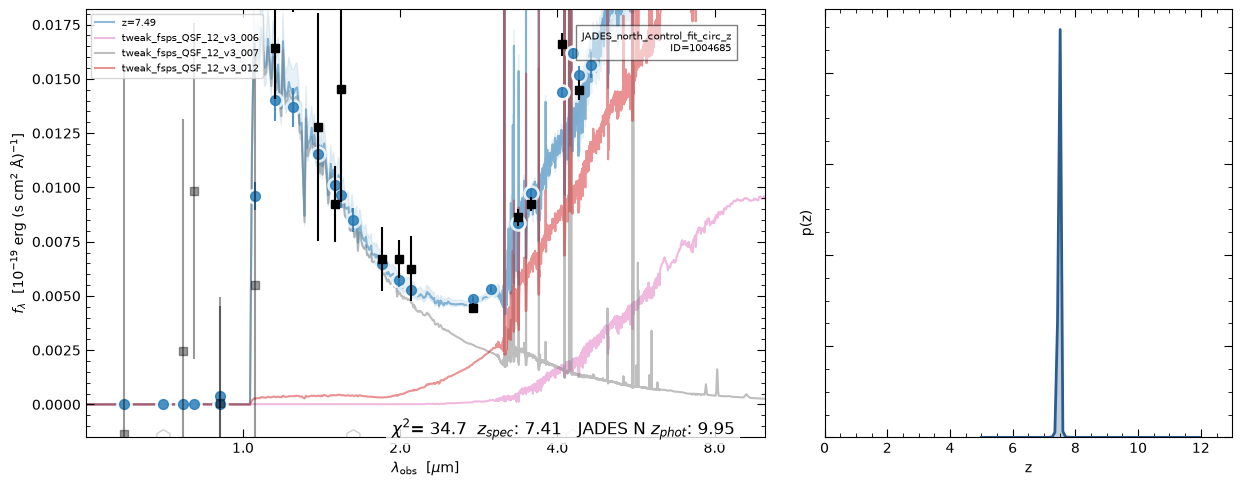

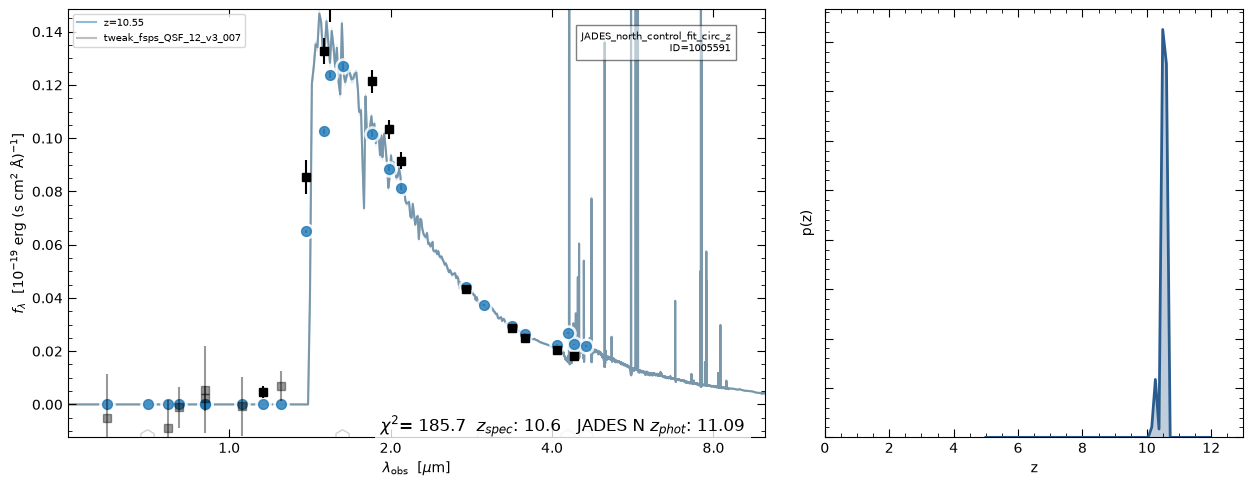

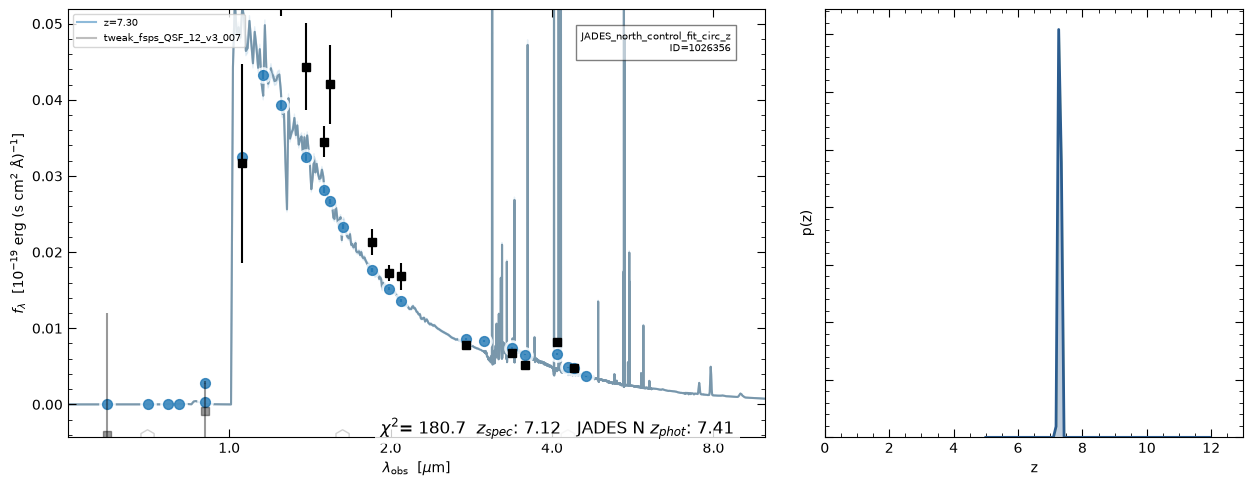

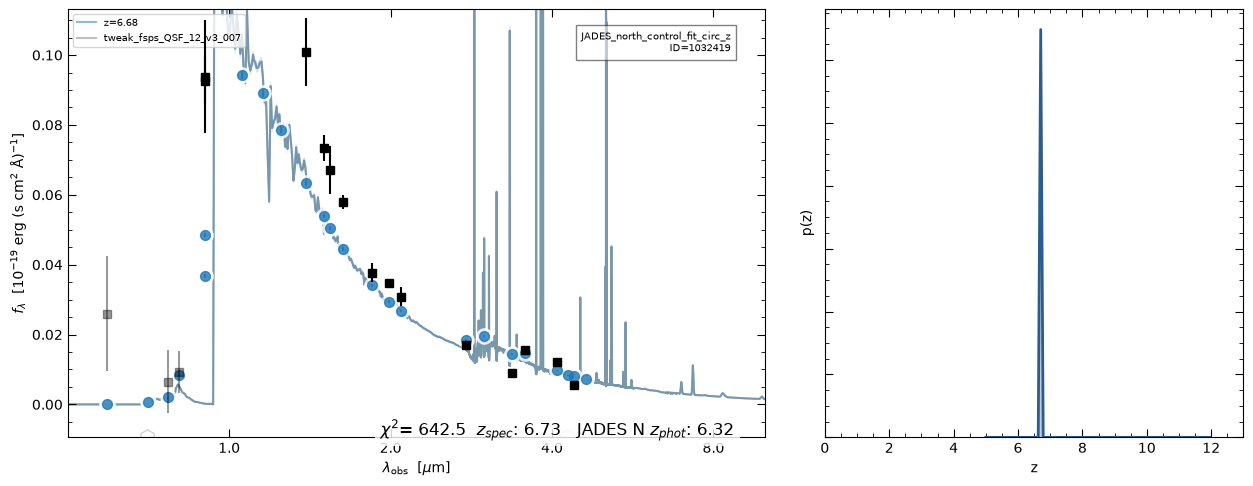

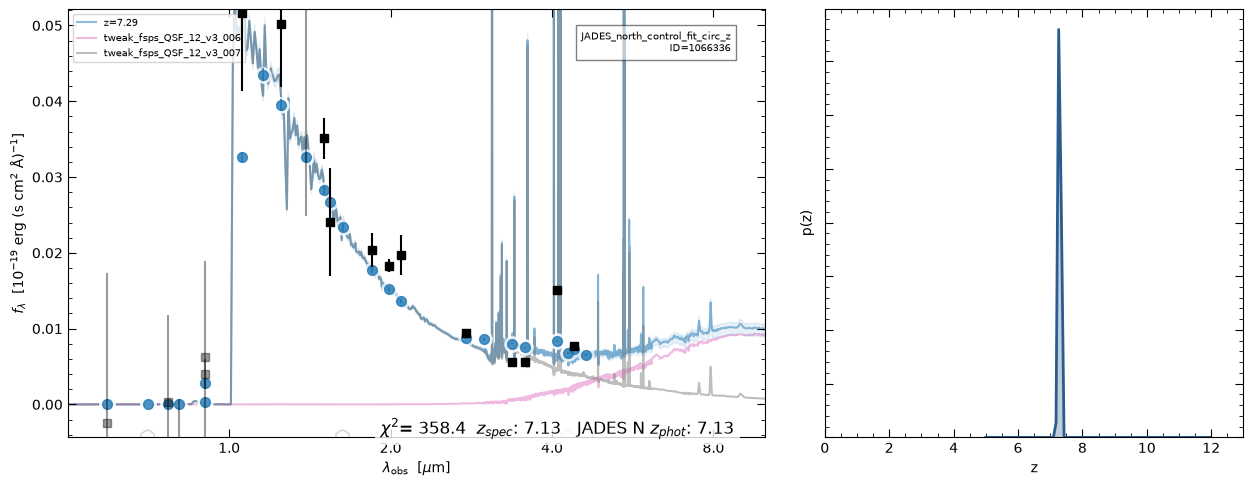

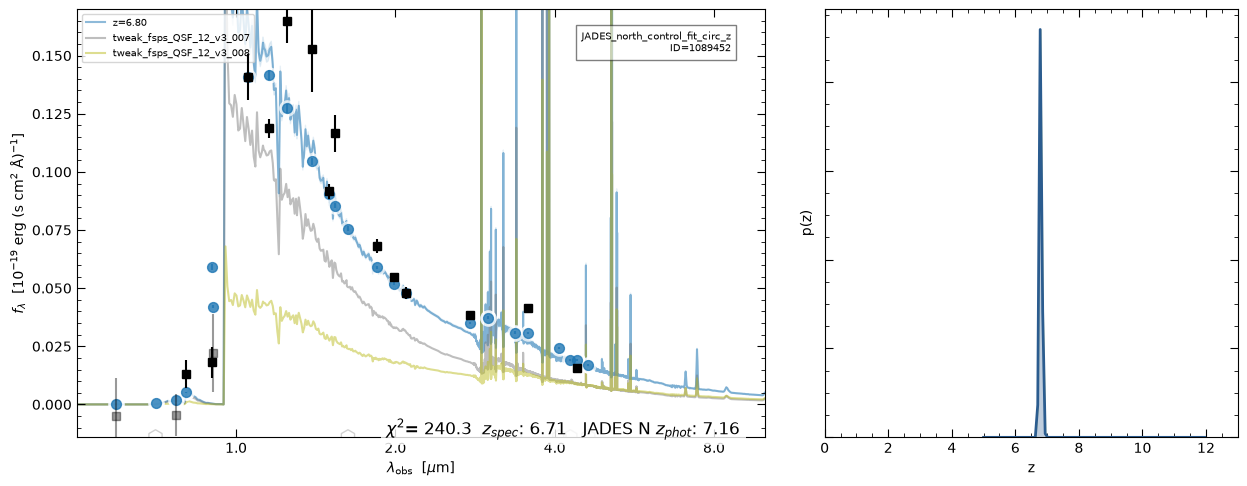

In [7]:
from matplotlib.ticker import AutoMinorLocator

output_path = '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/Tweak Fitting/JADES_north_control_fit_circ_z.zout.fits'
output_data = Table.read(output_path)

ids_index = []
for i in range(len(ids)):
    n = np.where(zout['id']==ids[i])[0]
    ids_index.append(n.item())
print(ids_index)

for i in range(len(ids)):
    fig, data = ez.show_fit(ids[i], xlim=[.5, 10], show_components=True,
                            logpz=False, zr=[0,13])
    # grab ax & figs
    ax = plt.gca()
    fig = plt.gcf()
    
    #fig.axes[0].set_ylim(0, 0.52)

    # set size to be wider
    fig.set_size_inches(13, 5)
    
    # remove grid lines
    ax1 = fig.axes[0]
    ax2 = fig.axes[1]
    ax1.grid(False)
    ax2.grid(False)
    
    # change p(z)
    ax1 = fig.axes[1]
    for line in ax1.get_lines():
        line.set_color('#2b5c8f')   
        line.set_linewidth(2.0)     
    for collection in ax1.collections:
        collection.set_facecolor('#2b5c8f') 
        collection.set_alpha(0.3)          
    if ax1.get_legend():
        ax1.legend(frameon=False)

    for ax in fig.axes:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        
        ax.tick_params(
            axis='both', 
            which='both', 
            direction='in',  
            top=True,        
            right=True
        )
        
        ax.tick_params(axis='both', which='major', length=6)
        ax.tick_params(axis='both', which='minor', length=3)

    ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"JADES N $z_{phot}$: " f"{jades_zphot[i]:.2f}", 
            fontsize=12,
            color='k',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')) 

In [8]:
from spectres import spectres
import warnings
from scipy.interpolate import interp1d
warnings.filterwarnings('ignore')

paths = [
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/north_spectra/jades_goods_north_1004685.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/north_spectra/jades_goods_north_1005591.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/north_spectra/jades_goods_north_1026356.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/north_spectra/jades_goods_north_1032419.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/north_spectra/jades_goods_north_1066336.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/north_spectra/jades_goods_north_1089452.fits'
]
'''
ylims = [.5,3,1,3,.8,2]
nrmsers = []
for i in range(len(ids)):
    
    # generate model data
    sed_data = ez.show_fit(id=ids[i], get_spec=True, show_fnu=0,renorm_t=False)
    wave_model = sed_data['templz']/10000  # Observed frame wavelength (microns when divided by 1e4)
    flux_model=sed_data['templf']*10 # multiply times ten to make to units of 10^-20 erg/s/cm2/AA

    # generate observed data
    data = Table.read(paths[i])
    wave_obs = data['WAVELENGTH']
    #flux_obs = data['FLUX']
    flux_obs = data['FLUX']/1e-20 # make into units of 10^-20 erg/s/cm^2/AA
    err_obs = data['FLUX_ERR erg s-1 cm-2 AA-1']/1e-20 # make into units of 10^-20 erg/s/cm^2/AA

    # interpolate model to fit the wavelength array of the observed data
    flux_model_interp = spectres(
        wave_obs,                # Target wavelength
        wave_model,              # model wavelength grid
        flux_model,             #  model flux
        fill=np.nan,             # Fill value for out-of-bounds wavelengths
        verbose=False
    )

    # mask any value less than the lyman alpha drop off because it is different physics there
    mask = (wave_obs > (.1216*(1+zspec[i]))-.08)

    # calculate the reduced chi^2
    res = ((flux_obs[mask]-flux_model_interp[mask])/err_obs[mask]) ** 2
    chi2 = np.sum(res)/len(flux_obs[mask])
    print(chi2)

    fig,ax = plt.subplots(figsize=(10,6))

    ax.plot(wave_obs[mask],flux_obs[mask],alpha=.5)
    ax.plot(wave_obs[mask],flux_model_interp[mask],alpha=.5)

    ax.set_xlabel(r'$\lambda_{obs} \text{ }[\mu m]$')
    ax.set_ylabel(r'Flux [$10^{-20}$ erg $(s \text{ } cm^2 \text{ } \mathrm{\AA})^{-1}]$')

    ax.set_ylim(0,ylims[i])
    ax.set_title(f'45K Templates, ID: {ids[i]}, zspec: {zspec[i]}, Chi2: {chi2:1f}')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
    ax.legend(['Observed Spectrum','Reconstructed Spectrum'],loc='upper right')
    ax.minorticks_on()
'''

<>:53: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1287914/1689516286.py:53: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel(r'$\lambda_{obs} \text{ }[\mu m]$')


"\nylims = [.5,3,1,3,.8,2]\nnrmsers = []\nfor i in range(len(ids)):\n\n    # generate model data\n    sed_data = ez.show_fit(id=ids[i], get_spec=True, show_fnu=0,renorm_t=False)\n    wave_model = sed_data['templz']/10000  # Observed frame wavelength (microns when divided by 1e4)\n    flux_model=sed_data['templf']*10 # multiply times ten to make to units of 10^-20 erg/s/cm2/AA\n\n    # generate observed data\n    data = Table.read(paths[i])\n    wave_obs = data['WAVELENGTH']\n    #flux_obs = data['FLUX']\n    flux_obs = data['FLUX']/1e-20 # make into units of 10^-20 erg/s/cm^2/AA\n    err_obs = data['FLUX_ERR erg s-1 cm-2 AA-1']/1e-20 # make into units of 10^-20 erg/s/cm^2/AA\n\n    # interpolate model to fit the wavelength array of the observed data\n    flux_model_interp = spectres(\n        wave_obs,                # Target wavelength\n        wave_model,              # model wavelength grid\n        flux_model,             #  model flux\n        fill=np.nan,             # Fill value

In [9]:
import numpy as np
from scipy.integrate import cumulative_trapezoid
# 1. The redshift evaluation grid (1D array)
zgrid = ez.zgrid

# 2. Extract the log-likelihood array
# Shape is (NOBJ, NZ) where NOBJ is catalog size, NZ is length of zgrid
lnp = ez.lnp

# 3. Convert log-likelihood to likelihood probability distribution P(z)
# Shift by max(lnp) per object before exponentiating to avoid numerical underflow
p_z = np.exp(lnp - np.max(lnp, axis=1, keepdims=True))

# 4. Normalize P(z) so the integral over z equals 1
p_z_norm = p_z / np.trapezoid(p_z, zgrid, axis=1)[:, np.newaxis]

z_lo = []
z_hi = []
for i in range(len(ids_index)):
    #if ids[i] == 159179:
        #continue

    cdf = cumulative_trapezoid(p_z_norm[ids_index][i], zgrid, initial=0)
    # Normalize CDF strictly to 1.0 just in case
    cdf /= cdf[-1]

    # 3. Interpolate to find the z values corresponding to the target percentiles
    z_16 = np.interp(0.16, cdf, zgrid)
    n = zout[ids_index][i]['z_phot'] - z_16
    z_lo.append(np.round(n,3).item())
    #z_50 = np.interp(0.50, cdf, zgrid)  # will use z_phot instead
    z_84 = np.interp(0.84, cdf, zgrid)
    n = z_84 - zout[ids_index][i]['z_phot']
    z_hi.append(np.round(n,3).item())

    #print(f"Redshift 16th percentile (z_16): {z_16:.3f}")
    #print(f"Chi^2 z_phot: {zout[ids_index][i]['z_phot']:.3f}")
    #print(f"Redshift 84th percentile (z_84): {z_84:.3f}")
    #print(f"1-sigma lower/upper bounds: z = {zout[ids_index][i]['z_phot']:.3f} +{z_84 - zout[ids_index][i]['z_phot']:.3f} -{zout[ids_index][i]['z_phot'] - z_16:.3f}")
    #print()
print(z_lo)
print(z_hi)
print(len(z_lo))


[0.055, 0.133, 0.074, 0.031, 0.073, 0.065]
[0.075, 0.092, 0.067, 0.073, 0.062, 0.057]
6


[7.492000102996826, 10.54800033569336, 7.296000003814697, 6.684000015258789, 7.291999816894531, 6.796000003814697]
[[0.055, 0.133, 0.074, 0.031, 0.073, 0.065], [0.075, 0.092, 0.067, 0.073, 0.062, 0.057]]


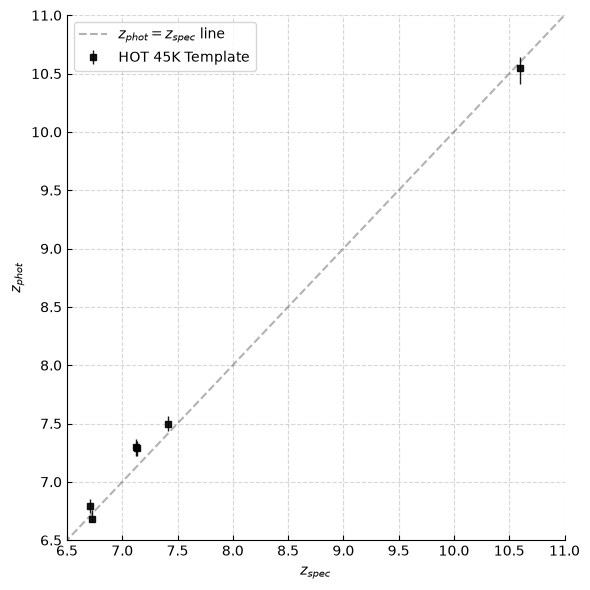

In [12]:
eazy_zphot = []
for i in range(len(ids_index)):
    n=output_data[ids_index[i]]['z_phot']
    eazy_zphot.append(np.round(n,3).item())
print(eazy_zphot)
err = [z_lo,z_hi]



fig,ax = plt.subplots(figsize=(6,6))
x = np.linspace(5,13,10)
y = np.linspace(5,13,10)
#ax.scatter(eazy_zphot,zspec,c='r',s=3)
print(err)

plt.errorbar(zspec, eazy_zphot, yerr=err, fmt='s',c='k',ms=5,elinewidth=1,alpha=0.9)
#ax.scatter(zspec,ceers_zphot,c='b',s=3)
#ax.scatter(zspec,ceers_zmed,c='b',s=3)
#plt.errorbar(zspec, ceers_zmed, yerr=ceers_err, fmt='s',c='b',ms=3,elinewidth=1,alpha=0.5)
ax.plot(x,y,alpha=0.3,c='k',linestyle='--')
ax.set_ylim(6.5,11)
ax.set_xlim(6.5,11)
ax.set_xlabel(r'$z_{spec}$')
ax.set_ylabel(r'$z_{phot}$')


ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend([r'$z_{phot} = z_{spec}$ line',"HOT 45K Template"])
plt.tight_layout()

Average HOT 45K Templates z_phot absolute error: 1.640e-02


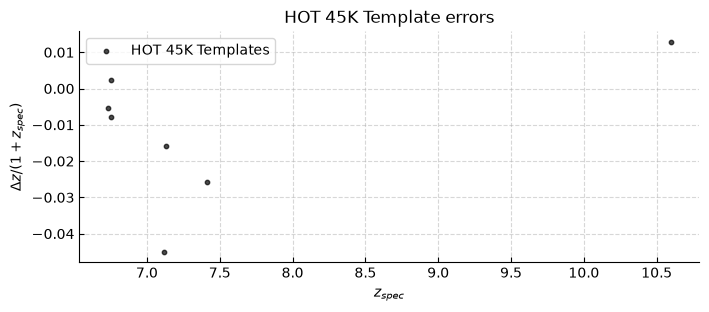

In [12]:
eazy_err = []
for i in range(len(zspec)):
    eazy_err.append((zspec[i]-eazy_zphot[i])/(1+zspec[i]))

print(f"Average HOT 45K Templates z_phot absolute error: {np.mean(np.abs(eazy_err)):.3e}")

fig,ax = plt.subplots(figsize=(8,3))
ax.scatter(zspec,eazy_err,alpha=0.7,c='k',s=10)
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("HOT 45K Template errors")
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.set_xlabel(r"$z_{spec}$")
ax.set_ylabel(r"$\Delta z/(1+z_{spec})$")
ax.legend(["HOT 45K Templates"])



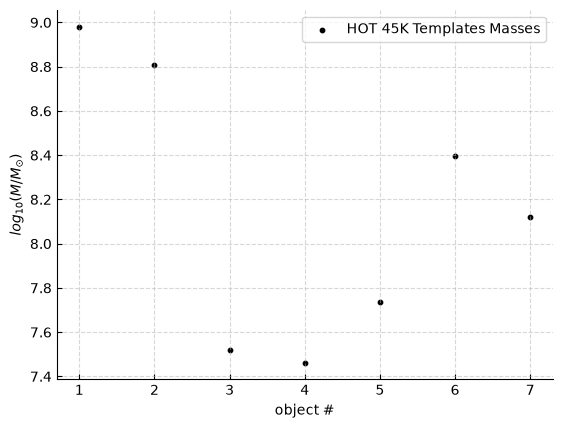

In [13]:
eazy_mass = []
n=len(zspec)
x = np.linspace(1,n,n)
for i in range(len(ids_index)):
    eazy_mass.append(np.log10(output_data[ids_index[i]]['mass']))
fig,ax = plt.subplots()
ax.scatter(x,eazy_mass,c='k',s=10)
ax.set_xlabel('object #')
ax.set_ylabel(r'$log_{10}(M/M_{\odot})$')
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(["HOT 45K Templates Masses"])
